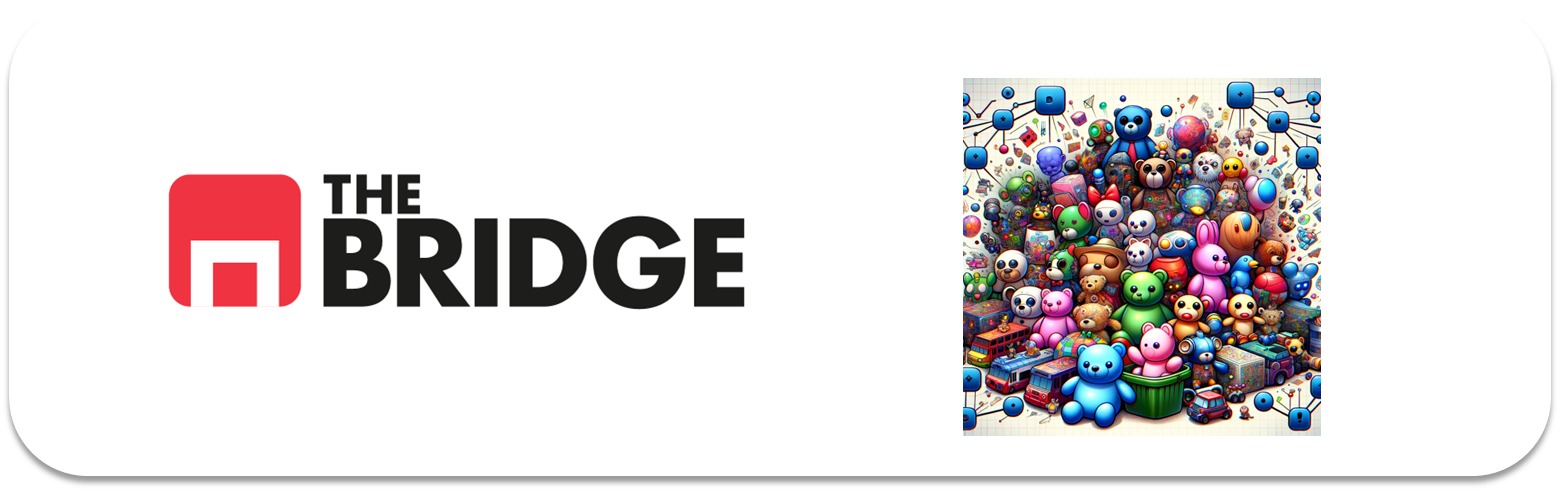

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [32]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, pairwise_distances_argmin
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering


import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


### **Carga y visualización de datos**

In [10]:
df = pd.read_csv("./data/empowering_drinks.csv", sep='|')
df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [12]:
df.describe()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
count,153.000000,153.000000,153.000000,153.000000,153.000000
mean,0.019231,0.037273,0.041057,0.080022,-0.044088
std,1.026182,0.995984,1.040928,1.009450,0.934399
min,-2.434235,-3.679162,-1.695971,-1.493188,-1.634288
25%,-0.816038,-0.499016,-1.043392,-0.738463,-0.799428
50%,0.061000,-0.023821,0.211566,-0.165254,-0.154899
75%,0.876275,0.707247,0.894264,0.917474,0.493956
max,2.259772,3.156325,3.062832,2.971473,2.431870


Observamos que las variables ya están escaladas(media próxima a 0 y desviación próxima a 1)

### **MiniEDA: Selección de features**

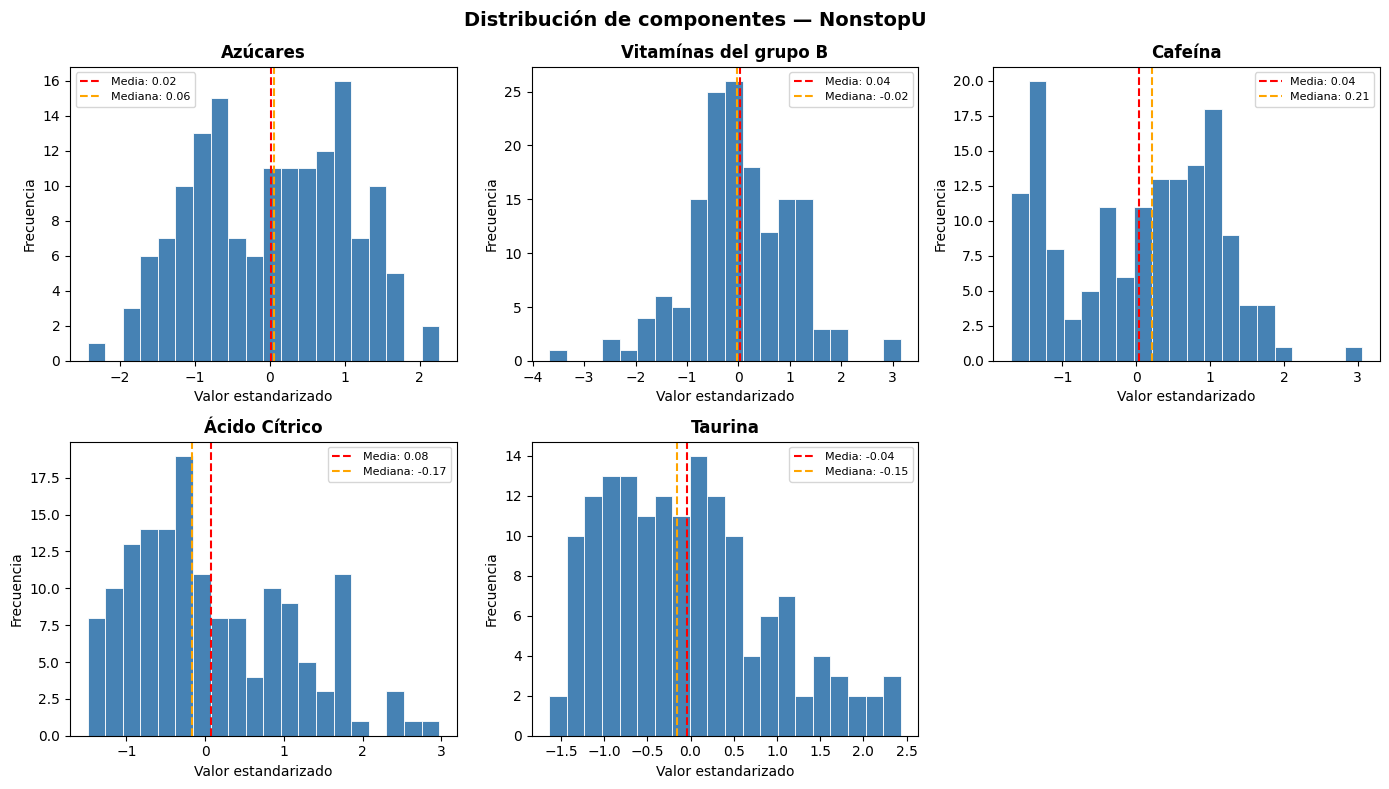

In [13]:
# Distribución de todas las features por separado
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='white', linewidth=0.6)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor estandarizado')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--', label=f'Media: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label=f'Mediana: {df[col].median():.2f}')
    axes[i].legend(fontsize=8)

axes[5].set_visible(False)
plt.suptitle('Distribución de componentes — NonstopU', fontsize=14, fontweight='bold')
plt.tight_layout()

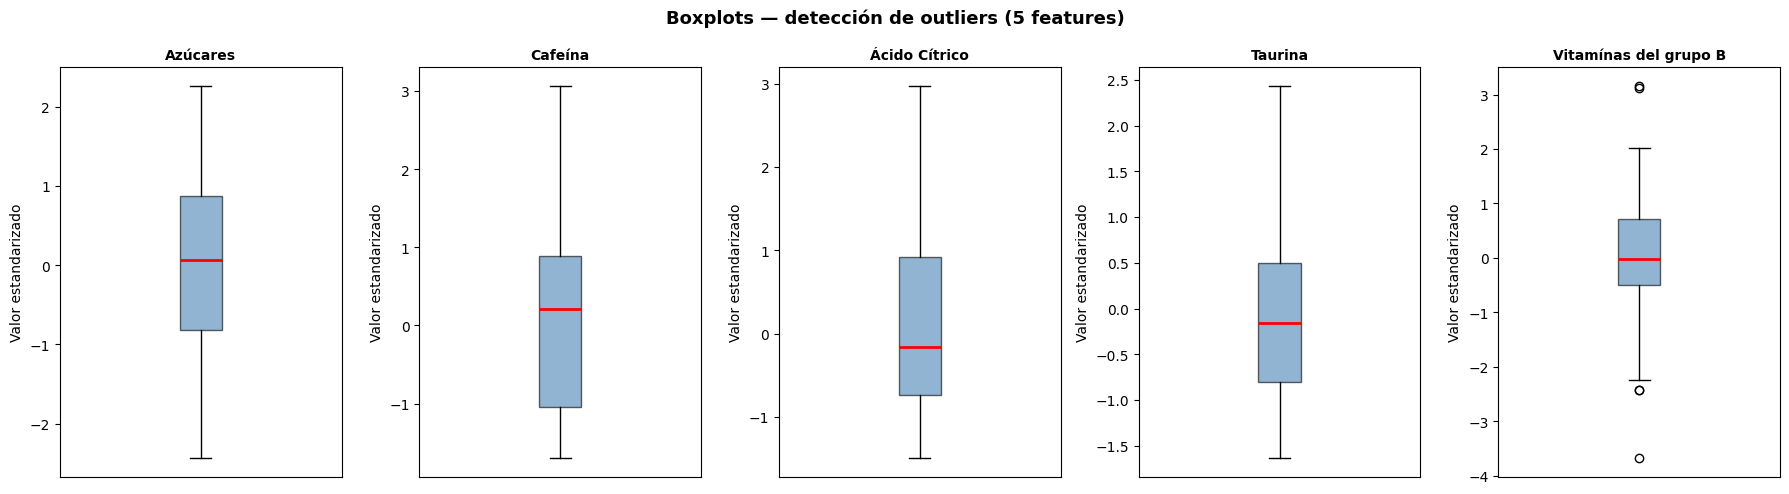

In [14]:
# Boxplot

features_todas = ['Azúcares', 'Cafeína', 'Ácido Cítrico', 'Taurina', 'Vitamínas del grupo B']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, col in enumerate(features_todas):
    bp = axes[i].boxplot(df[col], patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.6),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', color='darkorange', markersize=6))
    axes[i].set_title(col, fontsize=10, fontweight='bold')  # título en lugar de label en eje X
    axes[i].set_ylabel('Valor estandarizado')
    axes[i].set_xticks([])                                  # eliminar el "1" del eje X

plt.suptitle('Boxplots — detección de outliers (5 features)', fontsize=13, fontweight='bold')
plt.tight_layout()

Text(0.5, 1.01, 'Pairplot — componentes NonstopU')

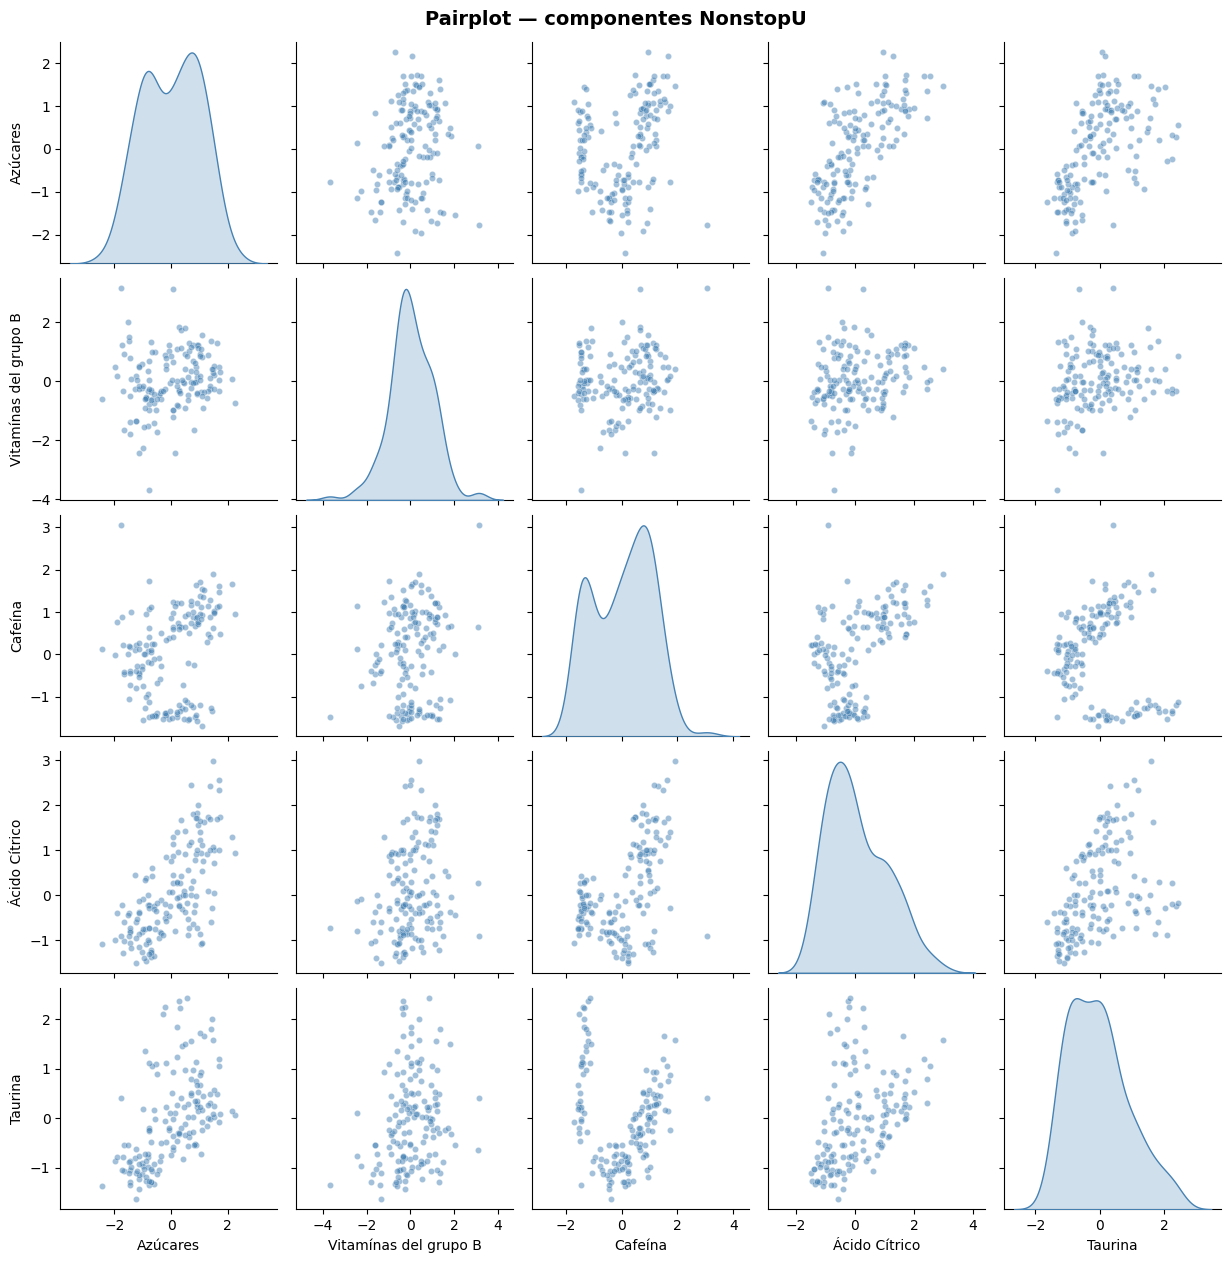

In [15]:
# Pairplot para ver las features dos a dos

g = sns.pairplot(df, diag_kind='kde',
                 plot_kws={'alpha': 0.5, 'color': 'steelblue', 's': 20},
                 diag_kws={'color': 'steelblue', 'fill': True})

g.figure.suptitle('Pairplot — componentes NonstopU', fontsize=14, fontweight='bold', y=1.01)

#### MiniEDA — Conclusiones generales

#### 1. Histogramas

- **Cafeína y Azúcares** presentan distribuciones claramente **bimodales**: dos picos bien diferenciados que sugieren la existencia de al menos dos grupos naturales en los datos.
- **Ácido Cítrico** también apunta a bimodalidad, aunque menos pronunciada.
- **Taurina** muestra una distribución más **unimodal y asimétrica**, sin picos tan definidos.
- **Vitaminas del grupo B** presenta la distribución más **uniforme y simétrica**, sin estructura aparente de grupos.
- Todas las variables tienen **media ≈ 0 y std ≈ 1**, lo que confirma que los datos ya están **estandarizados** en origen. No será necesario aplicar StandardScaler.

---

#### 2. Boxplots

- Outliers detectados solo en Vitaminas del grupo B.
- En el resto de features los bigotes cubren toda la distribución sin puntos externos, lo que es consistente con el pre-escalado de los datos.

---

#### 3. Pairplots / Scatterplots por pares

- **Cafeína** es la feature más discriminativa: muestra agrupaciones claras en todos sus pares (vs Azúcares, vs Ácido Cítrico, vs Taurina, vs Vitaminas B).
- **Azúcares** es la segunda feature más informativa: agrupaciones visibles frente a Cafeína y Taurina.
- **Ácido Cítrico** refuerza la separación especialmente en el par con Cafeína.
- **Taurina** aporta estructura adicional tanto con Cafeína como con Azúcares.
- **Vitaminas del grupo B** no muestra separación real en ningún par analizado — nubes de puntos difusas en todos los scatterplots.  
    Queda **descartada** para el modelado por no aportar poder discriminativo y porque además introduce ruido extremo que podría distorsinar el clustering.

---

#### 4. Conclusiones generales y decisiones

| Decisión | Detalle |
|---|---|
| **Features para modelado** | `Cafeína`, `Azúcares`, `Ácido Cítrico`, `Taurina` |
| **Feature descartada** | `Vitaminas del grupo B` — sin poder discriminativo y presencia de outliers|
| **Escalado** | No necesario — datos ya estandarizados en origen |
| **Outliers** | Solo presentes en feature descartada |
| **Nº de clusters esperado** | Entre 2 y 3 atendiendo a la bimodalidad observada, consistente con la hipótesis de los químicos (3-5 segmentos) |
| **Dataset final** | 153 muestras × 4 features |


In [16]:
# Features seleccionadas tras el miniEDA
features_selec = ['Azúcares', 'Cafeína', 'Ácido Cítrico', 'Taurina']
X = df[features_selec]

print(X.shape)

(153, 4)


### **Selección de modelos e hiperparámetros**

#### Empezamos con elbow + silhoutte para K-means dado que el enunciado nos orienta a entre 3 y 5

In [17]:
# Métrica por k
k_range = range(2, 9)
inercias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

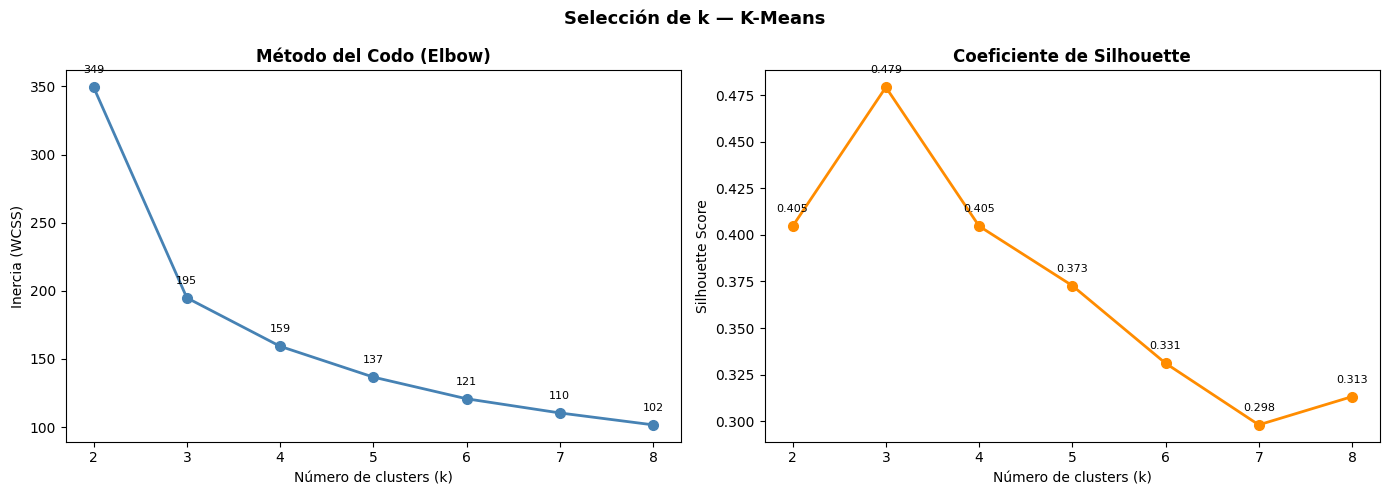

In [18]:
# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_range, inercias, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Método del Codo (Elbow)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_xticks(list(k_range))
for k, v in zip(k_range, inercias):
    axes[0].annotate(f'{v:.0f}', (k, v), textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')

# Silhouette
axes[1].plot(k_range, silhouettes, marker='o', color='darkorange', linewidth=2, markersize=7)
axes[1].set_title('Coeficiente de Silhouette', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))
for k, v in zip(k_range, silhouettes):
    axes[1].annotate(f'{v:.3f}', (k, v), textcoords="offset points", xytext=(0, 10), fontsize=8, ha='center')

plt.suptitle('Selección de k — K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()

#### Conclusion  
Ambas métricas apuntan de forma clara a `k=3`, que además coincide con el límite inferior del rango que los químicos consideran razonable


#### Continuamos con la búsqueda de hiperparámetros para DBSCAN (`eps` y `min_samples`)

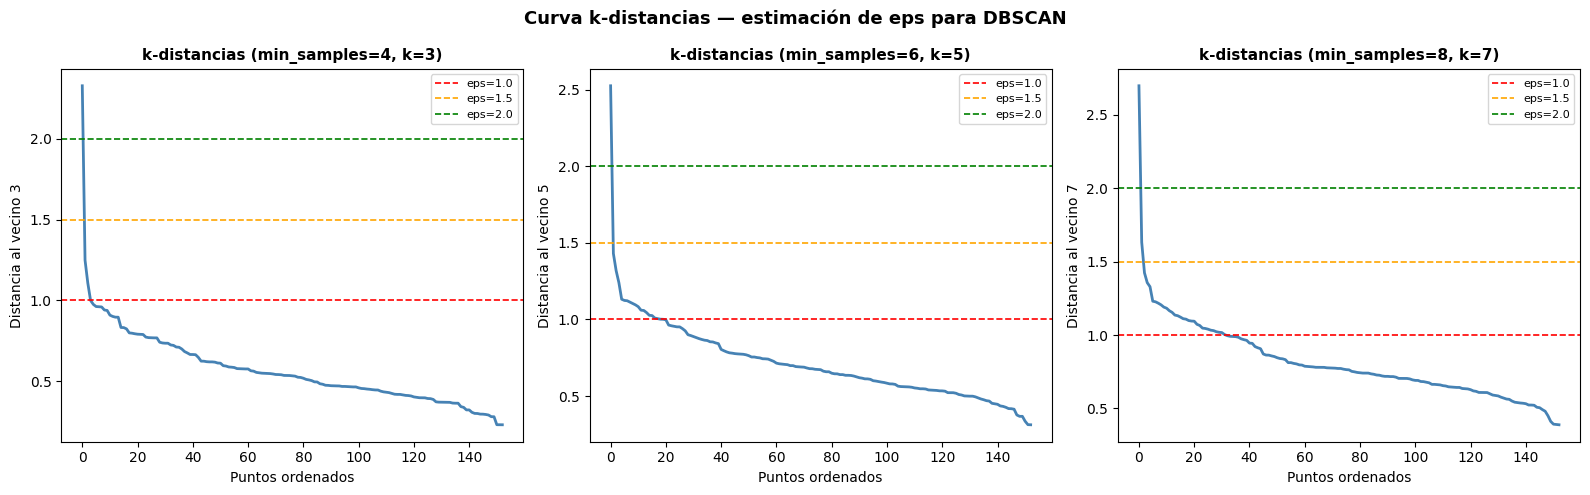

In [19]:
# ── Curva k-distancias ──────────────────────────────────
# Regla general: min_samples = 2 * n_features = 2 * 4 = 8

min_samples_candidates = [4, 6, 8]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, ms in enumerate(min_samples_candidates):
    k = ms - 1
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distancias, _ = nbrs.kneighbors(X)
    distancias_k = np.sort(distancias[:, -1])[::-1]  # ordenadas de mayor a menor

    axes[i].plot(distancias_k, color='steelblue', linewidth=2)
    axes[i].set_title(f'k-distancias (min_samples={ms}, k={k})', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Puntos ordenados')
    axes[i].set_ylabel(f'Distancia al vecino {k}')
    axes[i].axhline(y=1.0, color='red',    linestyle='--', linewidth=1.2, label='eps=1.0')
    axes[i].axhline(y=1.5, color='orange', linestyle='--', linewidth=1.2, label='eps=1.5')
    axes[i].axhline(y=2.0, color='green',  linestyle='--', linewidth=1.2, label='eps=2.0')
    axes[i].legend(fontsize=8)

plt.suptitle('Curva k-distancias — estimación de eps para DBSCAN', fontsize=13, fontweight='bold')
plt.tight_layout()



In [21]:
# ── Grid search ─────────────────────────────────────────
eps_values         = [0.8, 1.0, 1.2, 1.5, 2.0]
min_samples_values = [4, 6, 8]

print(f"{'eps':>6} | {'min_samples':>11} | {'n_clusters':>10} | {'n_noise':>7} | {'silhouette':>10}")
print("-" * 55)

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()

        # Silhouette solo es calculable con al menos 2 clusters
        if n_clusters >= 2:
            sil = silhouette_score(X, labels)
            print(f"{eps:>6} | {ms:>11} | {n_clusters:>10} | {n_noise:>7} | {sil:>10.4f}")
        else:
            print(f"{eps:>6} | {ms:>11} | {n_clusters:>10} | {n_noise:>7} | {'N/A (1 cluster)':>10}")

   eps | min_samples | n_clusters | n_noise | silhouette
-------------------------------------------------------
   0.8 |           4 |          2 |      16 |     0.2241
   0.8 |           6 |          2 |      23 |     0.2010
   0.8 |           8 |          3 |      30 |     0.3354
   1.0 |           4 |          2 |       4 |     0.2050
   1.0 |           6 |          2 |       5 |     0.2419
   1.0 |           8 |          2 |       6 |     0.2327
   1.2 |           4 |          1 |       1 | N/A (1 cluster)
   1.2 |           6 |          1 |       1 | N/A (1 cluster)
   1.2 |           8 |          1 |       1 | N/A (1 cluster)
   1.5 |           4 |          1 |       1 | N/A (1 cluster)
   1.5 |           6 |          1 |       1 | N/A (1 cluster)
   1.5 |           8 |          1 |       1 | N/A (1 cluster)
   2.0 |           4 |          1 |       0 | N/A (1 cluster)
   2.0 |           6 |          1 |       0 | N/A (1 cluster)
   2.0 |           8 |          1 |       0 | N/A

#### Decisión de hiperparámetros — DBSCAN

##### Hiperparámetros seleccionados

| Hiperparámetro | Valor elegido | Justificación |
|---|---|---|
| `eps` | 0.8 | Valor en el codo de la curva k-distancias |
| `min_samples` | 8 | Regla general: `2 * n_features = 2 * 4 = 8` |

---

##### Justificación detallada

###### Curva k-distancias
- El codo aparece entre distancia **0.8 y 1.0** en las tres curvas (min_samples = 4, 6, 8).
- Por encima de 1.0 la curva es plana → todos los puntos se conectan y los clusters colapsan.
- El rango de `eps` a explorar queda acotado entre **0.8 y 1.0**.

###### Grid search
- **`eps ≥ 1.2`** → 1 solo cluster en todos los casos. `eps` demasiado grande, DBSCAN conecta toda la nube.
- **`eps = 1.0`** → 2 clusters con poco ruido (4-6 puntos), pero no cumple la hipótesis de los químicos (mínimo 3 segmentos).
- **`eps = 0.8, min_samples = 4`** → 2 clusters, 16 puntos de ruido, silhouette 0.224.
- **`eps = 0.8, min_samples = 6`** → 2 clusters, 23 puntos de ruido, silhouette 0.201.
- **`eps = 0.8, min_samples = 8`** → **3 clusters**, 30 puntos de ruido, silhouette 0.335. ✅

---

##### Criterios de elección

`eps=0.8, min_samples=8` es la única combinación que cumple simultáneamente:

1. Produce **3 clusters** — coherente con la nota orientativa de los químicos (mínimo 3 segmentos).
2. Tiene el **silhouette más alto** (0.335) de todas las combinaciones válidas.
3. Respeta la **regla general** `min_samples = 2 * n_features = 2 * 4 = 8`.

---

##### Coste asumido

Los **30 puntos de ruido (~20%)** etiquetados como -1 no se consideran un problema sino
**información útil**: representan mezclas en zonas de transición entre segmentos, que los
químicos podrán analizar como casos frontera o mezclas atípicas.

### **Entrenamiento y visualización de resultados**

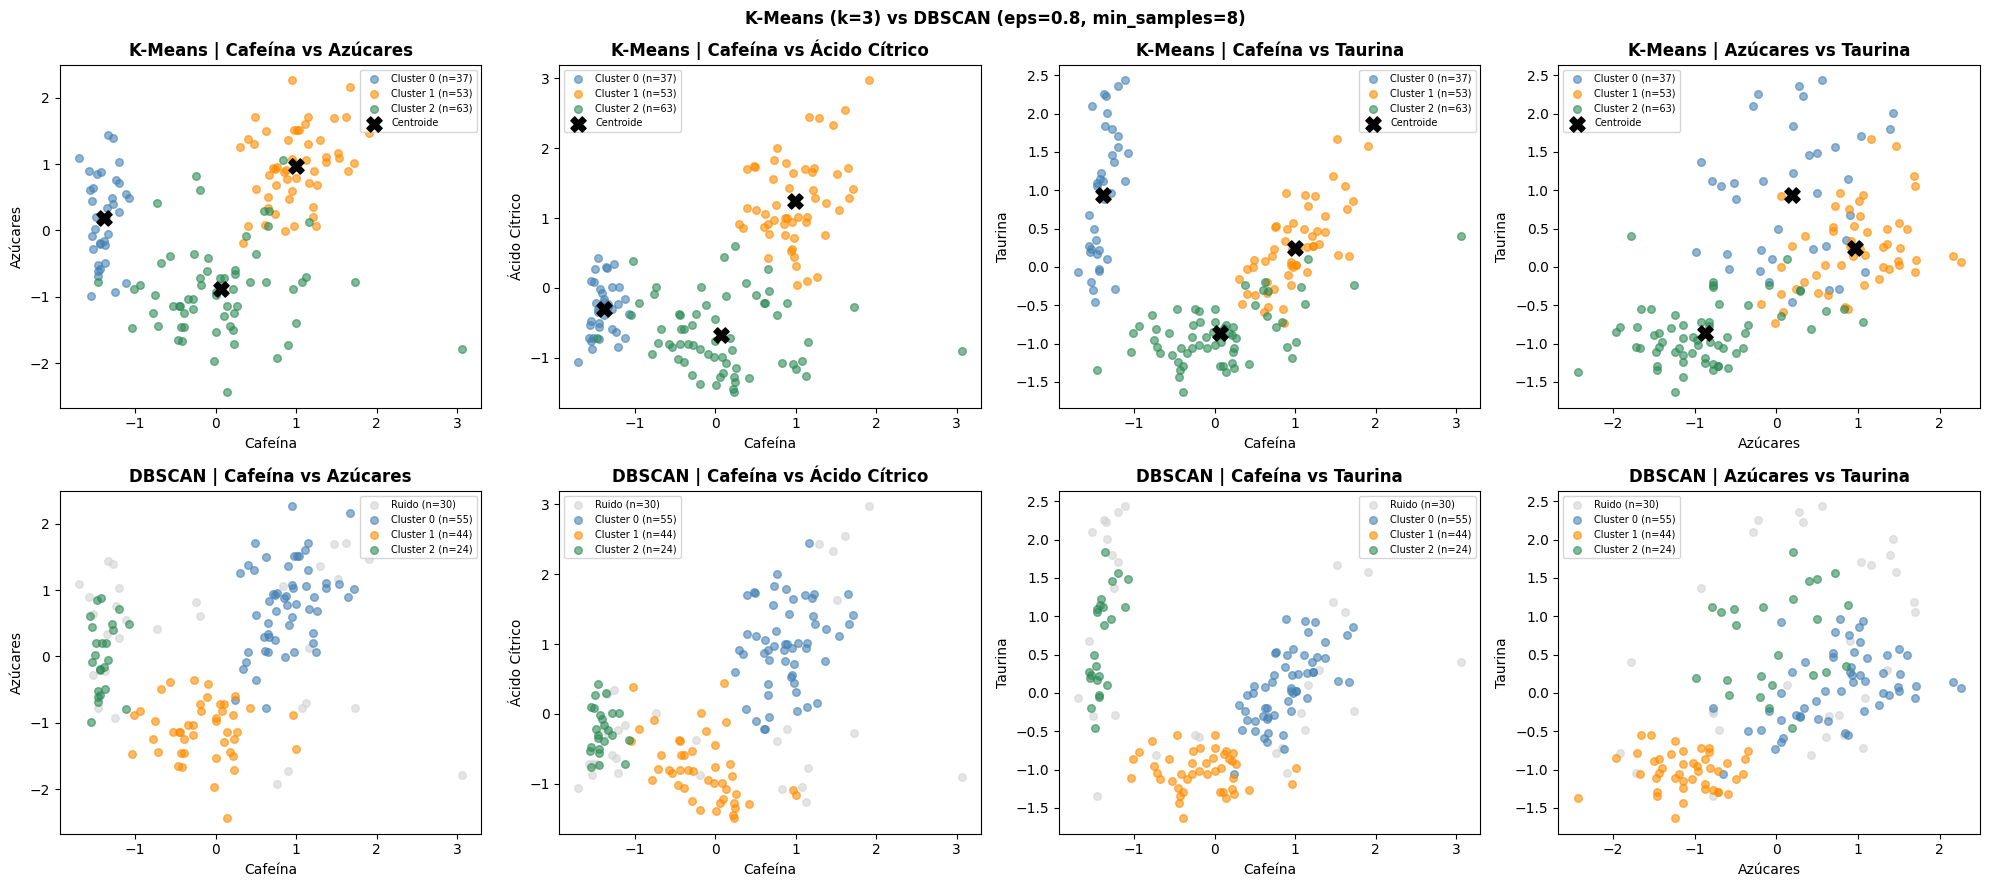

In [20]:
# ── Entrenamiento ────────────────────────────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km.fit_predict(X)

db = DBSCAN(eps=0.8, min_samples=8)
labels_db = db.fit_predict(X)

# ── Visualización ────────────────────────────────────────
pares = [
    ('Cafeína', 'Azúcares'),
    ('Cafeína', 'Ácido Cítrico'),
    ('Cafeína', 'Taurina'),
    ('Azúcares', 'Taurina'),
]

colores_km = ['steelblue', 'darkorange', 'seagreen']
colores_db = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for j, (x, y) in enumerate(pares):
    # K-Means — fila superior
    ax_km = axes[0][j]
    for cluster in np.unique(labels_km):
        mask = labels_km == cluster
        ax_km.scatter(X.loc[mask, x], X.loc[mask, y],
                      color=colores_km[cluster], alpha=0.6, s=30, label=f'Cluster {cluster} (n={mask.sum()})')
    ax_km.scatter(km.cluster_centers_[:, features.index(x)],
                  km.cluster_centers_[:, features.index(y)],
                  color='black', marker='X', s=120, zorder=5, label='Centroide')
    ax_km.set_xlabel(x); ax_km.set_ylabel(y)
    ax_km.set_title(f'K-Means | {x} vs {y}', fontweight='bold')
    ax_km.legend(fontsize=7)

    # DBSCAN — fila inferior
    ax_db = axes[1][j]
    for cluster in np.unique(labels_db):
        mask = labels_db == cluster
        color = 'lightgrey' if cluster == -1 else colores_db[cluster]
        label = f'Ruido (n={mask.sum()})' if cluster == -1 else f'Cluster {cluster} (n={mask.sum()})'
        ax_db.scatter(X.loc[mask, x], X.loc[mask, y],
                      color=color, alpha=0.6, s=30, label=label)
    ax_db.set_xlabel(x); ax_db.set_ylabel(y)
    ax_db.set_title(f'DBSCAN | {x} vs {y}', fontweight='bold')
    ax_db.legend(fontsize=7)

plt.suptitle('K-Means (k=3) vs DBSCAN (eps=0.8, min_samples=8)', fontsize=12, fontweight='bold')
plt.tight_layout()

# Discusión de resultados — Clustering NonstopU

## Métricas finales

| Modelo | Silhouette | Clusters | Ruido |
|---|---|---|---|
| K-Means (k=3) | 0.479 | 3 | 0 (0%) |
| DBSCAN (eps=0.8, min_samples=8) | 0.335 | 3 | 30 (19.6%) |

---

## Perfil de clusters — K-Means

| Cluster | n | Azúcares | Cafeína | Ácido Cítrico | Taurina | Interpretación |
|---|---|---|---|---|---|---|
| 0 | 37 | media | **muy baja** | baja | **alta** | Bajo estimulante, alto recuperador |
| 1 | 53 | **alta** | **alta** | **alta** | media | Fórmula intensa — alto en todo |
| 2 | 63 | **baja** | media | baja | **baja** | Fórmula suave — bajo en todo |

- K-Means produce clusters **equilibrados en tamaño** (37 / 53 / 63).
- Los perfiles son **claramente diferenciados** entre sí — especialmente en Cafeína y Ácido Cítrico.
- Silhouette de **0.479** indica clusters razonablemente compactos y bien separados.

---

## Perfil de clusters — DBSCAN

| Cluster | n | Azúcares | Cafeína | Ácido Cítrico | Taurina | Interpretación |
|---|---|---|---|---|---|---|
| 0 | 55 | **alta** | **alta** | **alta** | media | Fórmula intensa — coincide con KM cluster 1 |
| 1 | 44 | **baja** | baja | **baja** | **baja** | Fórmula suave — coincide con KM cluster 2 |
| 2 | 24 | media | **muy baja** | baja | **alta** | Bajo estimulante — coincide con KM cluster 0 |
| -1 (ruido) | 30 | disperso | disperso | disperso | disperso | Mezclas en zonas de transición |

- DBSCAN encuentra **los mismos 3 perfiles** que K-Means, lo que da solidez a la segmentación.
- Los **30 puntos de ruido** son mezclas en zonas de baja densidad entre clusters — no son errores
sino información: representan fórmulas en zonas de transición entre segmentos.
- Los clusters de DBSCAN son más **desiguales en tamaño** (55 / 44 / 24) al ser más estricto
con la densidad.

---

## ¿Por qué la comparación es especulativa?

- **Silhouette no es comparable directamente** entre ambos modelos: K-Means asigna el 100% de
los puntos, DBSCAN deja un 19.6% como ruido (-1) que penaliza su score. Un silhouette mayor
en K-Means no implica que sea un modelo mejor, sino que mide sobre distribuciones de etiquetas
distintas.
- **No tenemos ground truth** — al ser aprendizaje no supervisado sin etiquetas reales, no podemos
saber cuál de los dos modelos segmenta "correctamente". Solo podemos evaluar coherencia interna.
- La **interpretación final** corresponde a los químicos, que son quienes pueden validar si los
3 perfiles tienen sentido desde el punto de vista de la formulación de la bebida.

---

## Conclusión final

Ambos modelos convergen en **3 segmentos** con perfiles muy similares, lo que refuerza que la
estructura de 3 grupos es **robusta y real** en los datos:

- **Segmento A — Fórmula intensa:** alta Cafeína, altos Azúcares y Ácido Cítrico.
Perfil estimulante máximo.
- **Segmento B — Fórmula suave:** bajos en todos los componentes. Perfil de bebida ligera.
- **Segmento C — Bajo estimulante / alto recuperador:** muy baja Cafeína pero alta Taurina.
Perfil orientado a la recuperación más que al estímulo inmediato.

Los químicos tienen ahora una segmentación previa accionable para **priorizar qué prototipos
probar primero**, y los 30 puntos de ruido de DBSCAN son mezclas frontera que merecen atención
especial por estar entre dos perfiles y podrían representar variantes intermedias interesantes.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [28]:
df_new = pd.read_csv("./data/new_experiments.csv", sep='|')
print(df_new.shape)
df_new

(6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043


In [ ]:
# ── Reentrenamiento con datos originales ─────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


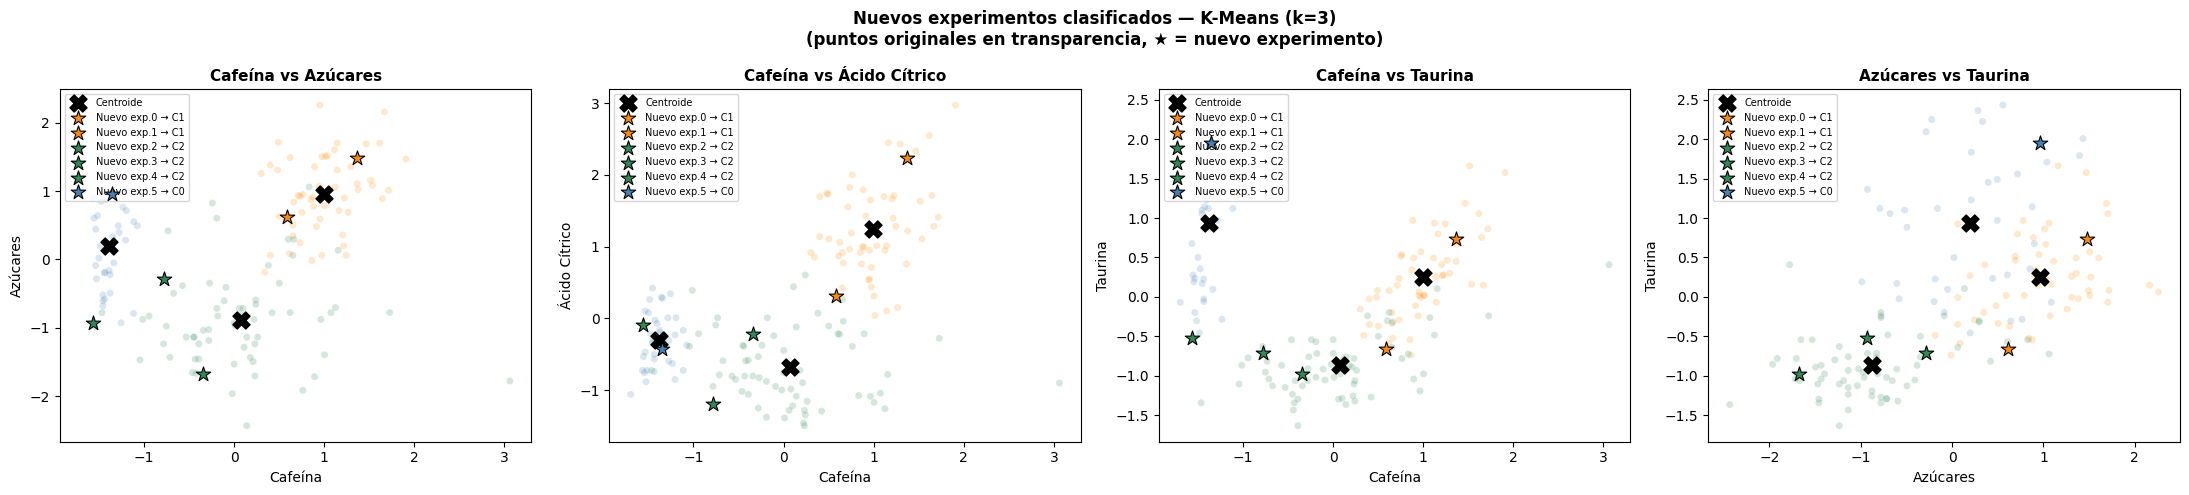

In [26]:
# ── Carga y predicción nuevos experimentos ───────────────
X_new = df_new[features_selec]          # descartamos Vitaminas B, igual que en entrenamiento

labels_new = km.predict(X_new)          # predict() asigna al centroide más cercano

# ── Visualización ────────────────────────────────────────
pares = [
    ('Cafeína', 'Azúcares'),
    ('Cafeína', 'Ácido Cítrico'),
    ('Cafeína', 'Taurina'),
    ('Azúcares', 'Taurina')
]

colores = ['steelblue', 'darkorange', 'seagreen']
labels_orig = km.labels_

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, (x, y) in enumerate(pares):
    ax = axes[i]                              

    # Puntos originales en transparencia
    for cluster in range(3):
        mask = labels_orig == cluster
        ax.scatter(X.loc[mask, x], X.loc[mask, y],
                   color=colores[cluster], alpha=0.2, s=25,
                   edgecolors='none')

    # Centroides
    ax.scatter(km.cluster_centers_[:, features_selec.index(x)],
               km.cluster_centers_[:, features_selec.index(y)],
               color='black', marker='X', s=150, zorder=5, label='Centroide')

    # Nuevos experimentos
    for exp_idx, cluster in enumerate(labels_new):
        ax.scatter(X_new.iloc[exp_idx][x], X_new.iloc[exp_idx][y],
                   color=colores[cluster], s=120, marker='*',
                   edgecolors='black', linewidths=0.8, zorder=6,
                   label=f'Nuevo exp.{exp_idx} → C{cluster}')

    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Nuevos experimentos clasificados — K-Means (k=3)\n'
             '(puntos originales en transparencia, ★ = nuevo experimento)',
             fontsize=12, fontweight='bold')
plt.tight_layout()

# Clustering NonstopU — Documento Final

---

# 1. Entendimiento del problema

Los químicos de una planta de experimentación de bebidas energéticas necesitan un sistema de **segmentación previa de mezclas** sin necesidad de probarlas. Disponen de datos históricos de mezclas con 5 componentes (`Azúcares`, `Vitaminas del grupo B`, `Cafeína`, `Ácido Cítrico`, `Taurina`) pero **sin etiquetas** — no se realizaron tests con usuarios. El objetivo es encontrar grupos naturales en los datos que los químicos puedan interpretar y usar para priorizar qué prototipos probar.

Se trata de un problema de **aprendizaje no supervisado — clustering**. Los químicos esperan entre **3 y 5 segmentos**.

---

# 2. Carga de datos

```python
import pandas as pd

df = pd.read_csv('data/empowering_drinks.csv', sep='|')
```

| Dimensión | Valor |
|---|---|
| Filas (mezclas) | 153 |
| Columnas (componentes) | 5 |
| Nulos | 0 |
| Duplicados | 0 |

- Todos los valores son `float64` — no hay variables categóricas.
- Los datos ya están **estandarizados** (media ≈ 0, std ≈ 1) — no será necesario aplicar StandardScaler.

---

# 3. MiniEDA — Selección de features

## Histogramas

- **Cafeína y Azúcares** presentan distribuciones claramente **bimodales** — dos picos bien diferenciados que sugieren al menos dos grupos naturales.
- **Ácido Cítrico** también apunta a bimodalidad, aunque menos pronunciada.
- **Taurina** muestra una distribución más unimodal y asimétrica.
- **Vitaminas del grupo B** presenta la distribución más uniforme, sin estructura de grupos.
- Todas las variables confirman el **pre-escalado** en origen.

## Boxplots

- **0 outliers** en las 4 features seleccionadas (`Azúcares`, `Cafeína`, `Ácido Cítrico`, `Taurina`).
- **Vitaminas del grupo B** muestra **3 outliers** (valores en ~3.0, ~-2.3 y ~-4.0) — argumento adicional para su descarte.
- No se requiere tratamiento de valores extremos para las features seleccionadas.

## Pairplots / Scatterplots por pares

- **Cafeína** es la feature más discriminativa — agrupaciones claras en todos sus pares.
- **Azúcares** es la segunda más informativa — agrupaciones visibles con Cafeína y Taurina.
- **Ácido Cítrico** refuerza la separación en el par con Cafeína.
- **Taurina** aporta estructura adicional con Cafeína y Azúcares.
- **Vitaminas del grupo B** no muestra separación real en ningún par — nubes difusas en todos los scatterplots.

## Decisión de features

| Feature | Decisión | Motivo |
|---|---|---|
| **Cafeína** | ✅ Seleccionada | Feature más discriminativa |
| **Azúcares** | ✅ Seleccionada | Segunda más informativa |
| **Ácido Cítrico** | ✅ Seleccionada | Refuerza separación con Cafeína |
| **Taurina** | ✅ Seleccionada | Estructura adicional — crítica para DBSCAN |
| **Vitaminas del grupo B** | ❌ Descartada | Sin poder discriminativo + outliers |

> **Dataset final para modelado: 153 muestras × 4 features**

---

# 4. Tratamiento de features

- **Escalado:** no necesario — datos ya estandarizados en origen.
- **Outliers:** no hay en las 4 features seleccionadas — no se requiere tratamiento.
- **Nulos:** ninguno — dataset limpio.

---

# 5. Selección de modelos e hiperparámetros

## Modelos seleccionados

| Modelo | Justificación |
|---|---|
| **K-Means** | Modelo de referencia para clustering con número de clusters acotado (3-5). Apropiado cuando se sospecha estructura globular en los datos, que es lo que sugieren los scatterplots. |
| **DBSCAN** | Requerido por el enunciado. Permite detectar clusters de forma arbitraria y marcar puntos de ruido — útil para identificar mezclas atípicas en zonas de transición. |

## Selección de k — K-Means (Elbow + Silhouette)

```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inercia = km.inertia_
    sil = silhouette_score(X, labels)
```

| k | Inercia | Silhouette |
|---|---|---|
| 2 | 349.42 | 0.405 |
| **3** | **194.82** | **0.479** ✅ |
| 4 | 159.27 | 0.405 |
| 5 | 136.65 | 0.373 |
| 6 | 120.74 | 0.331 |
| 7 | 110.35 | 0.298 |
| 8 | 101.61 | 0.313 |

- El **codo** se produce claramente en k=3.
- El **silhouette** es máximo en k=3 (0.479) y cae de forma sostenida para k≥4.
- Ambas métricas apuntan a **`k=3`**, coincidente con el mínimo del rango orientativo de los químicos.

## Selección de hiperparámetros — DBSCAN

```python
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Curva k-distancias para estimar eps
# Regla general: min_samples = 2 * n_features = 2 * 4 = 8
for ms in [4, 6, 8]:
    k = ms - 1
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distancias, _ = nbrs.kneighbors(X)
    distancias_k = np.sort(distancias[:, -1])[::-1]

# Grid search
for eps in [0.8, 1.0, 1.2, 1.5, 2.0]:
    for ms in [4, 6, 8]:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters >= 2:
            sil = silhouette_score(X, labels)
```

| eps | min_samples | n_clusters | n_ruido | silhouette |
|---|---|---|---|---|
| 0.8 | 4 | 2 | 16 | 0.224 |
| 0.8 | 6 | 2 | 23 | 0.201 |
| **0.8** | **8** | **3** | **30** | **0.335** ✅ |
| 1.0 | 4-8 | 2 | 4-6 | 0.205-0.242 |
| ≥1.2 | cualquiera | 1 | — | N/A |

**Hiperparámetros seleccionados: `eps=0.8, min_samples=8`**
- Única combinación que produce **3 clusters** — coherente con la hipótesis de los químicos.
- **Silhouette más alto** (0.335) de todas las combinaciones válidas.
- Respeta la regla general `min_samples = 2 * n_features`.

---

# 6. Entrenamiento y resultados

```python
from sklearn.cluster import KMeans, DBSCAN

km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = km.fit_predict(X)

db = DBSCAN(eps=0.8, min_samples=8)
labels_db = db.fit_predict(X)
```

## Métricas finales

| Modelo | Silhouette | Clusters | Ruido |
|---|---|---|---|
| K-Means (k=3) | 0.479 | 3 | 0 (0%) |
| DBSCAN (eps=0.8, min_samples=8) | 0.335 | 3 | 30 (19.6%) |

## Perfil de clusters — K-Means

| Cluster | n | Azúcares | Cafeína | Ácido Cítrico | Taurina | Interpretación |
|---|---|---|---|---|---|---|
| 0 | 37 | media | **muy baja** | baja | **alta** | Bajo estimulante / alto recuperador |
| 1 | 53 | **alta** | **alta** | **alta** | media | Fórmula intensa — alto en todo |
| 2 | 63 | **baja** | media | baja | **baja** | Fórmula suave — bajo en todo |

## Perfil de clusters — DBSCAN

| Cluster | n | Azúcares | Cafeína | Ácido Cítrico | Taurina | Interpretación |
|---|---|---|---|---|---|---|
| 0 | 55 | **alta** | **alta** | **alta** | media | Fórmula intensa — coincide con KM cluster 1 |
| 1 | 44 | **baja** | baja | **baja** | **baja** | Fórmula suave — coincide con KM cluster 2 |
| 2 | 24 | media | **muy baja** | baja | **alta** | Bajo estimulante — coincide con KM cluster 0 |
| -1 (ruido) | 30 | disperso | disperso | disperso | disperso | Mezclas en zonas de transición |

---

# 7. Discusión de resultados

## Convergencia de los modelos

Ambos modelos encuentran **los mismos 3 perfiles**, lo que refuerza que la estructura de 3 grupos es **robusta y real** en los datos:

- **Segmento A — Fórmula intensa:** alta Cafeína, altos Azúcares y Ácido Cítrico. Perfil estimulante máximo.
- **Segmento B — Fórmula suave:** bajos en todos los componentes. Perfil de bebida ligera.
- **Segmento C — Bajo estimulante / alto recuperador:** muy baja Cafeína pero alta Taurina. Perfil orientado a la recuperación más que al estímulo inmediato.

## ¿Por qué la comparación es especulativa?

- **Silhouette no es comparable directamente** entre ambos modelos: K-Means asigna el 100% de los puntos; DBSCAN deja un 19.6% como ruido (-1) que penaliza su score. Un silhouette mayor en K-Means no implica que sea mejor modelo.
- sin etiquetas reales no podemos saber cuál segmenta "correctamente". Solo evaluamos coherencia interna.
- La **interpretación final** corresponde a los químicos, que son quienes pueden validar si los 3 perfiles tienen sentido desde el punto de vista de la formulación.

## Valor de los puntos de ruido en DBSCAN

Los 30 puntos de ruido no son errores — son **mezclas en zonas de transición** entre segmentos. Pueden representar variantes intermedias interesantes que merezcan atención especial por parte de los químicos.

---

# Parte II — Nuevos experimentos

```python
df_new = pd.read_csv('data/new_experiments.csv', sep='|')
X_new = df_new[features]
labels_new = km.predict(X_new)
```

Se usa **K-Means** por ser el modelo más sencillo de aplicar a nuevos datos — `predict()` asigna directamente cada punto al centroide más cercano sin necesidad de reentrenar.

## Resultados

| Experimento | Azúcares | Cafeína | Ácido Cítrico | Taurina | Cluster | Perfil |
|---|---|---|---|---|---|---|
| 0 | alta | alta | **muy alta** | media | **1** | Fórmula intensa |
| 1 | media | media | media | baja | **1** | Fórmula intensa |
| 2 | **muy baja** | baja | baja | baja | **2** | Fórmula suave |
| 3 | baja | baja | **muy baja** | baja | **2** | Fórmula suave |
| 4 | baja | **muy baja** | baja | baja | **2** | Fórmula suave |
| 5 | alta | **muy baja** | baja | **muy alta** | **0** | Bajo estimulante / alto recuperador |

## Nota sobre visualización 2D

El experimento 4 (Cluster 2 — verde) puede parecer visualmente mal asignado en el par Cafeína vs Ácido Cítrico, al estar cerca de la zona del Cluster 0. Sin embargo K-Means toma decisiones en **4 dimensiones simultáneamente** — sus valores de Taurina y Azúcares lo acercan inequívocamente al Cluster 2. Esta es una limitación conocida de las visualizaciones 2D en clustering multidimensional: un punto puede parecer mal asignado en un par de features pero estar correctamente asignado en el espacio completo.


### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.

In [31]:
df_power = pd.read_csv("./data/power_results.csv", sep='|')
print(df_power.shape)
df_power.head()

(159, 1)


,class
0,1
1,1
2,1
3,1
4,1


In [ ]:
# Dataset completo: 153 originales + 6 nuevos
X_all  = pd.concat([X, X_new], ignore_index=True)
y_true = df_power['class'].values   # CLASIFICACION: 1=media, 2=media-alta, 3=alta

# K-Means — predict directo
labels_km = km.predict(X_all)

# ── DBSCAN ───────────────────────────────────────────────
# labels_db ya existe de la Parte I — contiene las etiquetas de los 153 originales
# Para los 6 nuevos: asignamos al centroide DBSCAN más cercano
centroides_db = np.array([X.values[labels_db == c].mean(axis=0) for c in [0, 1, 2]])
labels_db_new = pairwise_distances_argmin(X_new.values, centroides_db)
labels_db_all = np.concatenate([labels_db, labels_db_new])

# ── Métricas externas ────────────────────────────────────
ari_km = adjusted_rand_score(y_true, labels_km)
nmi_km = normalized_mutual_info_score(y_true, labels_km)
ari_db = adjusted_rand_score(y_true, labels_db_all)
nmi_db = normalized_mutual_info_score(y_true, labels_db_all)



Text(0.5, 1.0, 'DBSCAN vs Ground Truth\nARI=0.6494 | NMI=0.6577')

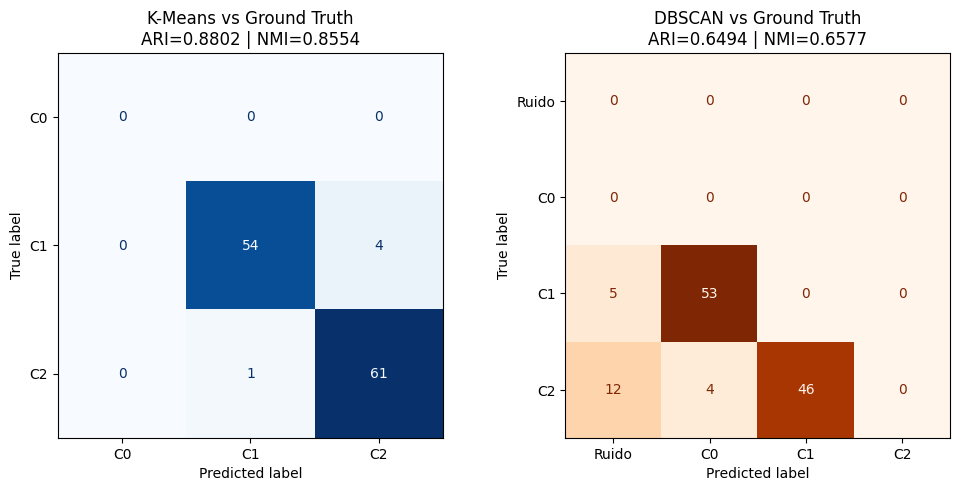

In [34]:
# ── Matrices de confusión ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_km = confusion_matrix(y_true, labels_km, labels=[0, 1, 2])
ConfusionMatrixDisplay(cm_km, display_labels=['C0', 'C1', 'C2']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'K-Means vs Ground Truth\nARI={ari_km:.4f} | NMI={nmi_km:.4f}')

cm_db = confusion_matrix(y_true, labels_db_all, labels=[-1, 0, 1, 2])
ConfusionMatrixDisplay(cm_db, display_labels=['Ruido', 'C0', 'C1', 'C2']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'DBSCAN vs Ground Truth\nARI={ari_db:.4f} | NMI={nmi_db:.4f}')

# Parte III — Evaluación externa (6 meses después)

## Contexto

La unidad de experimentación obtuvo presupuesto adicional y realizó tests con usuarios reales,
obteniendo etiquetas de **nivel de energización** para todas las mezclas:

| Nivel | Descripción | n |
|---|---|---|
| 1 | Energización media | 58 |
| 2 | Energización media-alta | 62 |
| 3 | Energización alta | 39 |

El fichero `power_results.csv` contiene 159 etiquetas — 153 mezclas originales + 6 nuevos experimentos de la Parte II — alineadas con el orden de los datos.

---

## Métricas de evaluación externa

Las métricas usadas son **independientes de la correspondencia de etiquetas** — no importa que
K-Means llame "Cluster 0" a lo que el ground truth llama "nivel 3". Miden si los puntos que
el modelo agrupa juntos son también los que la realidad agrupa juntos.

### ARI — Adjusted Rand Index
- Mide la **similitud entre dos particiones** de los datos.
- Rango: de -1 a 1. **1 = correspondencia perfecta**, 0 = agrupación aleatoria, negativo = peor que aleatorio.
- Está ajustado para corregir el azar — es más fiable que el Rand Index simple.

### NMI — Normalized Mutual Information
- Mide cuánta **información comparten** las etiquetas del modelo y el ground truth.
- Rango: de 0 a 1. **1 = información compartida total**, 0 = independencia total.
- Normalizado para que sea comparable entre particiones de distinto tamaño.

---

## Resultados

| Métrica | K-Means | DBSCAN |
|---|---|---|
| **ARI** | **0.8802** | 0.6494 |
| **NMI** | **0.8554** | 0.6577 |

---

## Interpretación

### K-Means
- ARI de **0.88** — extraordinariamente alto para aprendizaje no supervisado sin ninguna etiqueta
durante el entrenamiento. Significa que sus 3 clusters coinciden casi perfectamente con los
3 niveles de energización reales.
- NMI de **0.855** — el modelo comparte un 85.5% de información mutua con el ground truth.
- La correspondencia entre clusters y niveles reales es:

| Cluster K-Means | Nivel real de energización |
|---|---|
| Cluster 1 (Fórmula intensa) | Energización alta (3) |
| Cluster 2 (Fórmula suave) | Energización media (1) |
| Cluster 0 (Bajo estimulante / alto recuperador) | Energización media-alta (2) |

### DBSCAN
- ARI de **0.65** y NMI de **0.66** — notables, pero penalizados por los **30 puntos de ruido**
(-1) que quedan sin asignar y que en la evaluación computan como un "cluster" propio.
- La matriz de confusión tiene dimensiones **3×4** (incluye columna de ruido) frente a la
**3×3** de K-Means — refleja la realidad de que DBSCAN no asigna todos los puntos.
- Los puntos de ruido pertenecían a distintos niveles de energización, lo que confirma que
son mezclas genuinamente fronterizas entre segmentos.

---

## Conclusión final

**K-Means fue el modelo más acertado**, con una segmentación no supervisada que resultó ser
una aproximación casi perfecta a la realidad descubierta 6 meses después.

Esto valida retrospectivamente todas las decisiones tomadas durante el proceso:
- La selección de 4 features (`Azúcares`, `Cafeína`, `Ácido Cítrico`, `Taurina`).
- El descarte de `Vitaminas del grupo B`.
- La elección de `k=3` respaldada por el elbow y el silhouette.
- La interpretación de los 3 segmentos como perfiles de energización diferenciados.

> La segmentación no supervisada, construida sin ninguna etiqueta, anticipó correctamente
> la estructura real de los datos con un ARI de 0.88 — un resultado excepcional que
> demuestra que los componentes químicos de la bebida son predictores muy fuertes de
> su capacidad energizante.
